# Tutorial aGrUM (C++)

This notebook mirrors the [pyAgrum tutorial](../../wrappers/pyagrum/doc/sphinx/notebooks/01-Tutorial_pyAgrum.ipynb), but in C++ using the `%%cpp` magic provided by `gum_cppnb` (installed by `act install aGrUM`, see `src/gum_cppnb/README.md` for the design rationale).

**Important difference with the Python tutorial**: each `%%cpp` cell here is compiled and run as its own standalone program (its own `main()`). There is *no* state shared between cells -- unlike the Python kernel, a variable built in one cell does not exist in the next. Cells that build on a previous step therefore rebuild what they need from scratch.

In [1]:
%load_ext gum_cppnb

## Creating your first Bayesian network with aGrUM

(This example is based on an OpenBayes [closed] website tutorial, same as the pyAgrum version.)

A **Bayesian network** (BN) is composed of **random variables** (nodes) and their conditional dependencies (arcs), forming a directed acyclic graph. A **conditional probability table** (CPT) is associated with each node.

We build the classic *Water Sprinkler* network: 4 binary variables `c` (cloudy?), `s` (sprinkler?), `r` (rain?), `w` (wet grass?), with `c->s`, `c->r`, `s->w`, `r->w`.

### Create the network topology

BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}
0
c:Range([0,1])
1 2 3
BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}


[0]

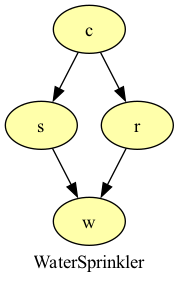

In [2]:
%%cpp
#include <agrum/bn.h>

int main() {
  gum::BayesNet<double> bn("WaterSprinkler");
  std::cout << bn.toString() << std::endl;

  // add(fast_description, default_nbrmod) is a shortcut for
  // add(gum::LabelizedVariable(name, name, default_nbrmod))
  gum::NodeId id_c = bn.add("c", 2);
  std::cout << id_c << std::endl;
  std::cout << bn.variable(id_c) << std::endl;

  gum::NodeId id_s = bn.add("s", 2);
  gum::NodeId id_r = bn.add("r", 2);
  gum::NodeId id_w = bn.add("w", 2);
  std::cout << id_s << " " << id_r << " " << id_w << std::endl;

  bn.addArc("c", "s");
  bn.addArc("c", "r");
  bn.addArc("s", "w");
  bn.addArc("r", "w");
  std::cout << bn.toString() << std::endl;

  cppnb_add_dot(bn.toDot());
}

### Shortcut with fastPrototype

The `fastPrototype` static method encodes topology and variable type in a concise language derived from `dot`, exactly like pyAgrum's `fastBN`:

BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}


[0]

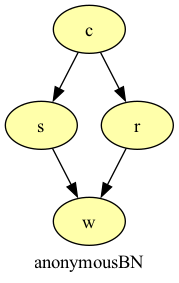

In [3]:
%%cpp
#include <agrum/bn.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("c->s->w<-r<-c");
  std::cout << bn.toString() << std::endl;
  cppnb_add_dot(bn.toDot());
}

### Create the probability tables

Once the topology is set, we fill each CPT (a `Tensor<double>` in aGrUM).

For a CPT with **no parent**, `fillWith({...})` is unambiguous -- one value per state of the variable:

In [4]:
%%cpp
#include <agrum/bn.h>

int main() {
  gum::BayesNet<double> bn("WaterSprinkler");
  bn.add("c", 2);
  bn.cpt("c").fillWith({0.5, 0.5});
  std::cout << bn.cpt("c") << std::endl;
}


  c                │
0        │1        │
─────────│─────────│
 0.5000  │ 0.5000  │



For a CPT **with parents**, `fillWith` needs a flat vector in aGrUM's internal variable order, which is easy to get wrong. `gum::Instantiation`, addressed by variable **name**, is the safer, order-independent equivalent of pyAgrum's dictionary-style `bn.cpt("w")[{"r": 0, "s": 0}] = [1, 0]`:


             ║  w                │
s     │r     ║0        │1        │
──────│──────║─────────│─────────│
0     │0     ║ 1.0000  │ 0.0000  │
1     │0     ║ 0.1000  │ 0.9000  │
0     │1     ║ 0.1000  │ 0.9000  │
1     │1     ║ 0.0100  │ 0.9900  │



[0]

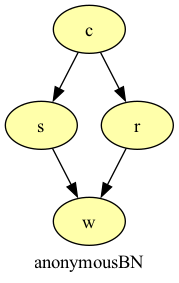

In [5]:
%%cpp
#include <agrum/bn.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("c->s->w<-r<-c");

  bn.cpt("c").fillWith({0.5, 0.5});

  gum::Instantiation is(bn.cpt("s"));
  is.chgVal("c", 0).chgVal("s", 0);
  bn.cpt("s").set(is, 0.5);
  is.chgVal("s", 1);
  bn.cpt("s").set(is, 0.5);
  is.chgVal("c", 1).chgVal("s", 0);
  bn.cpt("s").set(is, 0.9);
  is.chgVal("s", 1);
  bn.cpt("s").set(is, 0.1);

  gum::Instantiation ir(bn.cpt("r"));
  ir.chgVal("c", 0).chgVal("r", 0);
  bn.cpt("r").set(ir, 0.8);
  ir.chgVal("r", 1);
  bn.cpt("r").set(ir, 0.2);
  ir.chgVal("c", 1).chgVal("r", 0);
  bn.cpt("r").set(ir, 0.2);
  ir.chgVal("r", 1);
  bn.cpt("r").set(ir, 0.8);

  gum::Instantiation iw(bn.cpt("w"));
  iw.chgVal("r", 0).chgVal("s", 0).chgVal("w", 0);
  bn.cpt("w").set(iw, 1.0);
  iw.chgVal("w", 1);
  bn.cpt("w").set(iw, 0.0);
  iw.chgVal("r", 0).chgVal("s", 1).chgVal("w", 0);
  bn.cpt("w").set(iw, 0.1);
  iw.chgVal("w", 1);
  bn.cpt("w").set(iw, 0.9);
  iw.chgVal("r", 1).chgVal("s", 0).chgVal("w", 0);
  bn.cpt("w").set(iw, 0.1);
  iw.chgVal("w", 1);
  bn.cpt("w").set(iw, 0.9);
  iw.chgVal("r", 1).chgVal("s", 1).chgVal("w", 0);
  bn.cpt("w").set(iw, 0.01);
  iw.chgVal("w", 1);
  bn.cpt("w").set(iw, 0.99);

  std::cout << bn.cpt("w") << std::endl;
  cppnb_add_dot(bn.toDot());
}

### Input/output

aGrUM ships writers/readers for several formats under `agrum/BN/io/` (BIF, net, UAI, XDSL, BIFXML, ...). We use **jgum** here -- aGrUM's own JSON serialization (`gum::GumBNWriter`/`gum::GumBNReader`, text mode when `binary=false`) -- written to a local `out/` directory (git-ignored, created if needed).

In [20]:
%%cpp
#include <agrum/bn.h>
#include <agrum/BN/io/GUM/GumBNWriter.h>
#include <agrum/BN/io/GUM/GumBNReader.h>
#include <agrum/BN/inference/lazyPropagation.h>
#include <filesystem>
#include <fstream>

int main() {
  std::filesystem::create_directories("out");

  auto bn = gum::BayesNet<double>::fastPrototype("c->s->w<-r<-c");
  bn.cpt("c").fillWith({0.5, 0.5});
  bn.cpt("s").fillWith({0.5, 0.5, 0.9, 0.1});
  bn.cpt("r").fillWith({0.8, 0.2, 0.2, 0.8});
  bn.cpt("w").fillWith({1.0, 0.0, 0.1, 0.9, 0.1, 0.9, 0.01, 0.99});

  gum::GumBNWriter<double> writer(false, 2);   // text (jgum), indent=2
  writer.write("out/WaterSprinkler.gum", bn);

  std::ifstream in("out/WaterSprinkler.gum");
  std::string head, line;
  int no=1;
  while( std::getline(in, line))
    head += std::format("{:02d} {}",no++,line) + "\n";
  std::cout << head << std::endl;

  gum::BayesNet<double> bn2;
  auto reader = gum::GumBNReader<double>(&bn2, "out/WaterSprinkler.gum");
  std::cout << "read back, errors: " << reader.proceed() << std::endl;

  std::cout << "P(w|r,s) original:\n" << bn.cpt("w") << std::endl;
  std::cout << "P(w|r,s) round-trip:\n" << bn.cpt("w") << std::endl;
}

01 {
02   "type": "BN",
03   "GumJsonVersion": "1.0",
04   "nodes": [
05     "c[2]",
06     "s[2]",
07     "w[2]",
08     "r[2]"
09   ],
10   "parents": {
11     "c": [],
12     "s": [
13       "c"
14     ],
15     "w": [
16       "s",
17       "r"
18     ],
19     "r": [
20       "c"
21     ]
22   },
23   "cpt": {
24     "c": [
25       0.5,
26       0.5
27     ],
28     "s": [
29       0.5,
30       0.5,
31       0.9,
32       0.1
33     ],
34     "w": [
35       1.0,
36       0.0,
37       0.1,
38       0.9,
39       0.1,
40       0.9,
41       0.01,
42       0.99
43     ],
44     "r": [
45       0.8,
46       0.2,
47       0.2,
48       0.8
49     ]
50   },
51   "properties": {
52     "name": "anonymousBN",
53     "software": "aGrUM 3.0.0.9",
54     "creation": "2026-08-09 20:58:05.814",
55     "lastModification": "2026-08-09 20:58:05.814"
56   }
57 }

read back, errors: 0
P(w|r,s) original:

             ║  w                │
s     │r     ║0        │1        │
──────│──────║──────

### Inference: LazyPropagation

We choose `gum::LazyPropagation`, an exact inference engine (transforms the BN into a junction tree). We rebuild the filled BN from the previous cell -- again, no shared state across cells.

In [7]:
%%cpp
#include <agrum/bn.h>
#include <agrum/BN/inference/lazyPropagation.h>

gum::BayesNet<double> buildWaterSprinkler() {
  auto bn = gum::BayesNet<double>::fastPrototype("c->s->w<-r<-c");

  bn.cpt("c").fillWith({0.5, 0.5});

  // fillWith flattens with the last-added parent varying slowest and the
  // child varying fastest -- here: s|c as [c=0: s=0,1][c=1: s=0,1].
  bn.cpt("s").fillWith({0.5, 0.5, 0.9, 0.1});
  bn.cpt("r").fillWith({0.8, 0.2, 0.2, 0.8});

  // w|r,s: r varies slowest, then s, then w fastest --
  // [r=0,s=0][r=0,s=1][r=1,s=0][r=1,s=1], each pair = w=0,1.
  bn.cpt("w").fillWith({1.0, 0.0, 0.1, 0.9, 0.1, 0.9, 0.01, 0.99});

  return bn;
}

int main() {
  auto bn = buildWaterSprinkler();

  gum::LazyPropagation ie(&bn);
  ie.makeInference();
  std::cout << "P(w) without evidence:\n" << ie.posterior("w") << std::endl;

  // hard evidence: sprinkler is on, it is not cloudy
  ie.addEvidence("s", 0);
  ie.addEvidence("c", 0);
  ie.makeInference();
  std::cout << "P(w | s=0, c=0):\n" << ie.posterior("w") << std::endl;

  // soft/likelihood evidence: partial belief over s and c
  ie.eraseAllEvidence();
  ie.addEvidence("s", std::vector<double>{0.5, 1});
  ie.addEvidence("c", std::vector<double>{1, 0});
  ie.makeInference();
  std::cout << "P(w | soft evidence on s,c):\n" << ie.posterior("w") << std::endl;
}

P(w) without evidence:

  w                │
0        │1        │
─────────│─────────│
 0.3529  │ 0.6471  │

P(w | s=0, c=0):

  w                │
0        │1        │
─────────│─────────│
 0.8200  │ 0.1800  │

P(w | soft evidence on s,c):

  w                │
0        │1        │
─────────│─────────│
 0.3280  │ 0.6720  │



## Testing independence in Bayesian networks

aGrUM/pyAgrum comes with tools to query the conditional independences readable directly from the graph structure.

A and C are independent.
A and C are NOT independent given the rest.
E and C are NOT independent.


[0]

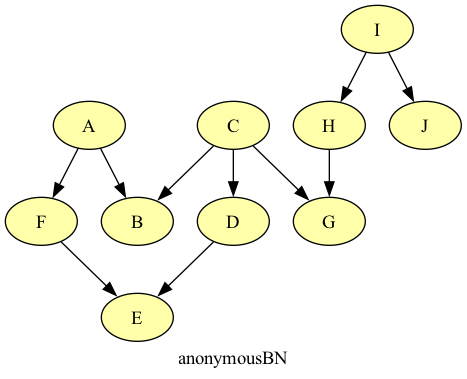

In [8]:
%%cpp
#include <agrum/bn.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("A->B<-C->D->E<-F<-A;C->G<-H<-I->J");
  cppnb_add_dot(bn.toDot());

  auto say = [](std::string_view x, std::string_view y,
                const std::vector<std::string>& knowing, bool indep) {
    std::cout << x << " and " << y << " are " << (indep ? "" : "NOT ")
              << "independent" << (knowing.empty() ? "." : " given the rest.") << std::endl;
  };

  say("A", "C", {}, bn.isIndependent("A", "C", {}));
  say("A", "C", {"E"}, bn.isIndependent("A", "C", {"E"}));
  say("E", "C", {}, bn.isIndependent("E", "C", {}));
}

### Markov Blanket

The Markov blanket of a node `X` is the set of nodes making `X` independent from the rest of the network.

digraph "no_name" {
node [shape = ellipse];
  0[label="A"];
  1[label="B"];
  2[label="C", color=red];
  3[label="D"];
  6[label="G"];
  7[label="H"];

  0 -> 1;
  2 -> 3;
  2 -> 1;
  2 -> 6;
  7 -> 6;

}



[0],[1]

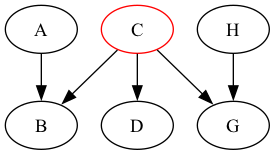
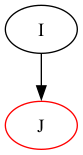

In [9]:
%%cpp
#include <agrum/bn.h>
#include <agrum/BN/algorithms/MarkovBlanket.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("A->B<-C->D->E<-F<-A;C->G<-H<-I->J");

  gum::MarkovBlanket mbC(bn, "C");
  std::cout << mbC.toDot() << std::endl;
  cppnb_add_dot(mbC.toDot());

  gum::MarkovBlanket mbJ(bn, "J");
  cppnb_add_dot(mbJ.toDot());
}

### Minimal conditioning set and evidence impact

Given a target and a set of candidate evidence variables, `minimalCondSet` finds the sublist that actually impacts the target; `evidenceImpact` computes $P(target|evidence)$ while reducing the evidence set the same way.

In [10]:
%%cpp
#include <agrum/bn.h>
#include <agrum/BN/inference/lazyPropagation.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("A->B<-C->D->E<-F<-A;C->G<-H<-I->J");
  for (const auto& node : bn.nodes())
    bn.cpt(node).fillWith(1).normalize();

  auto minset = bn.minimalCondSet(bn.idFromName("B"),
                                   gum::NodeSet{bn.idFromName("A"), bn.idFromName("H"), bn.idFromName("J")});
  std::cout << "minimalCondSet(B, {A,H,J}) has " << minset.size() << " node(s)" << std::endl;

  gum::LazyPropagation ie(&bn);
  auto impact = ie.evidenceImpact("B", {"A", "C", "H", "G"});
  std::cout << impact << std::endl;
}

minimalCondSet(B, {A,H,J}) has 1 node(s)

             ║  B                │
A     │C     ║0        │1        │
──────│──────║─────────│─────────│
0     │0     ║ 0.5000  │ 0.5000  │
1     │0     ║ 0.5000  │ 0.5000  │
0     │1     ║ 0.5000  │ 0.5000  │
1     │1     ║ 0.5000  │ 0.5000  │

